In [1]:
pip install torch torchvision transformers datasets pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
from datasets import load_dataset

dataset = load_dataset("ashraq/fashion-product-images-small", split="train")
print(dataset)
print(dataset[0])

Dataset({
    features: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image'],
    num_rows: 44072
})
{'id': 15970, 'gender': 'Men', 'masterCategory': 'Apparel', 'subCategory': 'Topwear', 'articleType': 'Shirts', 'baseColour': 'Navy Blue', 'season': 'Fall', 'year': 2011.0, 'usage': 'Casual', 'productDisplayName': 'Turtle Check Men Navy Blue Shirt', 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80 at 0x21CFFED0980>}


In [3]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'masterCategory': dataset['masterCategory'],
    'subCategory': dataset['subCategory'],
    'articleType': dataset['articleType'],
    'gender': dataset['gender'],
    'image': dataset['image'],
})

# 카테고리별 가격 규칙
price_map = {
    'Topwear': (15, 80),
    'Bottomwear': (20, 100),
    'Dress': (30, 150),
    'Innerwear': (10, 50),
    'Footwear': (30, 200),
    'Bags': (20, 300),
    'Watches': (50, 500),
    'Jewellery': (10, 200),
    'Eyewear': (20, 150),
    'Belts': (10, 80),
    'Socks': (5, 30),
    'Scarves': (10, 60),
}

def assign_price(subcat):
    low, high = price_map.get(subcat, (10, 100))
    return round(np.random.uniform(low, high), 2)

np.random.seed(42)
df['price'] = df['subCategory'].apply(assign_price)

print(df[['masterCategory', 'subCategory', 'articleType', 'price']].head(10))
print("\n가격 통계:")
print(df.groupby('subCategory')['price'].describe().round(2))

  masterCategory subCategory  articleType   price
0        Apparel     Topwear       Shirts   39.35
1        Apparel  Bottomwear        Jeans   96.06
2    Accessories     Watches      Watches  379.40
3        Apparel  Bottomwear  Track Pants   67.89
4        Apparel     Topwear      Tshirts   25.14
5        Apparel     Topwear      Tshirts   25.14
6        Apparel     Topwear       Shirts   18.78
7        Apparel     Topwear       Shirts   71.30
8    Accessories       Socks        Socks   20.03
9    Accessories     Watches      Watches  368.63

가격 통계:
                            count    mean     std    min     25%     50%  \
subCategory                                                                
Accessories                 129.0   57.79   25.97  10.29   34.95   59.03   
Apparel Set                 106.0   52.49   26.69  10.08   29.02   50.68   
Bags                       3053.0  161.62   81.05  20.01   92.30  161.60   
Bath and Body                 9.0   45.17   30.63  14.50   22.

In [4]:
from sklearn.preprocessing import LabelEncoder

# Label encoding
le_master = LabelEncoder()
le_sub = LabelEncoder()

df['masterCategory_label'] = le_master.fit_transform(df['masterCategory'])
df['subCategory_label'] = le_sub.fit_transform(df['subCategory'])

# Price normalization (0~1)
df['price_norm'] = (df['price'] - df['price'].min()) / (df['price'].max() - df['price'].min())

print(f"masterCategory classes: {le_master.classes_}")
print(f"subCategory classes: {le_sub.classes_}")
print(f"\nTotal data: {len(df)}")
print(f"masterCategory class count: {len(le_master.classes_)}")
print(f"subCategory class count: {len(le_sub.classes_)}")
print(df[['masterCategory', 'masterCategory_label', 'subCategory', 'subCategory_label', 'price', 'price_norm']].head(5))

masterCategory classes: ['Accessories' 'Apparel' 'Footwear' 'Free Items' 'Home' 'Personal Care'
 'Sporting Goods']
subCategory classes: ['Accessories' 'Apparel Set' 'Bags' 'Bath and Body' 'Beauty Accessories'
 'Belts' 'Bottomwear' 'Cufflinks' 'Dress' 'Eyes' 'Eyewear' 'Flip Flops'
 'Fragrance' 'Free Gifts' 'Gloves' 'Hair' 'Headwear' 'Home Furnishing'
 'Innerwear' 'Jewellery' 'Lips' 'Loungewear and Nightwear' 'Makeup'
 'Mufflers' 'Nails' 'Perfumes' 'Sandal' 'Saree' 'Scarves'
 'Shoe Accessories' 'Shoes' 'Skin' 'Skin Care' 'Socks'
 'Sports Accessories' 'Sports Equipment' 'Stoles' 'Ties' 'Topwear'
 'Umbrellas' 'Vouchers' 'Wallets' 'Watches' 'Water Bottle' 'Wristbands']

Total data: 44072
masterCategory class count: 7
subCategory class count: 45
  masterCategory  masterCategory_label subCategory  subCategory_label   price  \
0        Apparel                     1     Topwear                 38   39.35   
1        Apparel                     1  Bottomwear                  6   96.06   
2    Ac

In [5]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from torch.utils.data import Dataset, DataLoader

# Load CLIP model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model_clip = model_clip.to(device)

print("CLIP loaded successfully!")

Using device: cpu


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP loaded successfully!


In [6]:
print(model_clip)
print("CLIP is ready!")

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [7]:
from torch.utils.data import Dataset, DataLoader

class FashionDataset(Dataset):
    def __init__(self, dataframe, processor):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = row['image'].convert("RGB")
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze(0)

        master_label = torch.tensor(row['masterCategory_label'], dtype=torch.long)
        sub_label = torch.tensor(row['subCategory_label'], dtype=torch.long)
        price = torch.tensor(row['price_norm'], dtype=torch.float)

        return pixel_values, master_label, sub_label, price

# Use 5000 samples for speed
df_small = df.sample(5000, random_state=42).reset_index(drop=True)

train_size = int(0.8 * len(df_small))
train_df = df_small[:train_size]
val_df = df_small[train_size:]

train_dataset = FashionDataset(train_df, processor)
val_dataset = FashionDataset(val_df, processor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")
print("DataLoader ready!")

Train: 4000, Val: 1000
DataLoader ready!


In [8]:
import torch.nn as nn

class MultiTaskFashionModel(nn.Module):
    def __init__(self, clip_model, num_master, num_sub):
        super().__init__()
        self.clip = clip_model
        
        # Freeze CLIP weights
        for param in self.clip.parameters():
            param.requires_grad = False
        
        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Task heads
        self.master_head = nn.Linear(256, num_master)  # category classification
        self.sub_head = nn.Linear(256, num_sub)        # subcategory classification
        self.price_head = nn.Linear(256, 1)            # price regression

    def forward(self, pixel_values):
        # Extract image features from CLIP
        image_features = self.clip.get_image_features(pixel_values=pixel_values)
        
        # Fusion
        x = self.fusion(image_features)
        
        # Three outputs
        master_out = self.master_head(x)
        sub_out = self.sub_head(x)
        price_out = self.price_head(x).squeeze(1)
        
        return master_out, sub_out, price_out

num_master = len(le_master.classes_)  # 7
num_sub = len(le_sub.classes_)        # 45

model = MultiTaskFashionModel(model_clip, num_master, num_sub).to(device)
print(model)
print(f"\nnum_master: {num_master}, num_sub: {num_sub}")
print("Model ready!")

MultiTaskFashionModel(
  (clip): CLIPModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=2048, out_features=512, bias=

In [9]:
import torch.optim as optim

# Loss functions
criterion_master = nn.CrossEntropyLoss()
criterion_sub = nn.CrossEntropyLoss()
criterion_price = nn.MSELoss()

# Optimizer (only train fusion + heads, CLIP is frozen)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    correct_master = 0
    correct_sub = 0
    total = 0

    for pixel_values, master_label, sub_label, price in loader:
        pixel_values = pixel_values.to(device)
        master_label = master_label.to(device)
        sub_label = sub_label.to(device)
        price = price.to(device)

        optimizer.zero_grad()
        master_out, sub_out, price_out = model(pixel_values)

        loss_master = criterion_master(master_out, master_label)
        loss_sub = criterion_sub(sub_out, sub_label)
        loss_price = criterion_price(price_out, price)
        loss = loss_master + loss_sub + loss_price

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct_master += (master_out.argmax(1) == master_label).sum().item()
        correct_sub += (sub_out.argmax(1) == sub_label).sum().item()
        total += len(master_label)

    return total_loss / len(loader), correct_master / total, correct_sub / total

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct_master = 0
    correct_sub = 0
    total = 0

    with torch.no_grad():
        for pixel_values, master_label, sub_label, price in loader:
            pixel_values = pixel_values.to(device)
            master_label = master_label.to(device)
            sub_label = sub_label.to(device)
            price = price.to(device)

            master_out, sub_out, price_out = model(pixel_values)

            loss_master = criterion_master(master_out, master_label)
            loss_sub = criterion_sub(sub_out, sub_label)
            loss_price = criterion_price(price_out, price)
            loss = loss_master + loss_sub + loss_price

            total_loss += loss.item()
            correct_master += (master_out.argmax(1) == master_label).sum().item()
            correct_sub += (sub_out.argmax(1) == sub_label).sum().item()
            total += len(master_label)

    return total_loss / len(loader), correct_master / total, correct_sub / total

print("Training functions ready!")

Training functions ready!


In [10]:
NUM_EPOCHS = 5
train_losses, val_losses = [], []
train_master_accs, val_master_accs = [], []
train_sub_accs, val_sub_accs = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_master_acc, train_sub_acc = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_master_acc, val_sub_acc = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_master_accs.append(train_master_acc)
    val_master_accs.append(val_master_acc)
    train_sub_accs.append(train_sub_acc)
    val_sub_accs.append(val_sub_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Master Acc: {train_master_acc:.4f} | Sub Acc: {train_sub_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Master Acc: {val_master_acc:.4f} | Sub Acc: {val_sub_acc:.4f}")
    print()

Epoch 1/5
  Train Loss: 1.6637 | Master Acc: 0.9135 | Sub Acc: 0.7065
  Val   Loss: 0.5116 | Master Acc: 0.9920 | Sub Acc: 0.8900

Epoch 2/5
  Train Loss: 0.5494 | Master Acc: 0.9840 | Sub Acc: 0.8865
  Val   Loss: 0.3312 | Master Acc: 0.9940 | Sub Acc: 0.9180

Epoch 3/5
  Train Loss: 0.3981 | Master Acc: 0.9865 | Sub Acc: 0.9147
  Val   Loss: 0.2878 | Master Acc: 0.9950 | Sub Acc: 0.9280

Epoch 4/5
  Train Loss: 0.3221 | Master Acc: 0.9900 | Sub Acc: 0.9275
  Val   Loss: 0.2840 | Master Acc: 0.9930 | Sub Acc: 0.9280

Epoch 5/5
  Train Loss: 0.2827 | Master Acc: 0.9900 | Sub Acc: 0.9347
  Val   Loss: 0.2584 | Master Acc: 0.9960 | Sub Acc: 0.9300



Model saved!


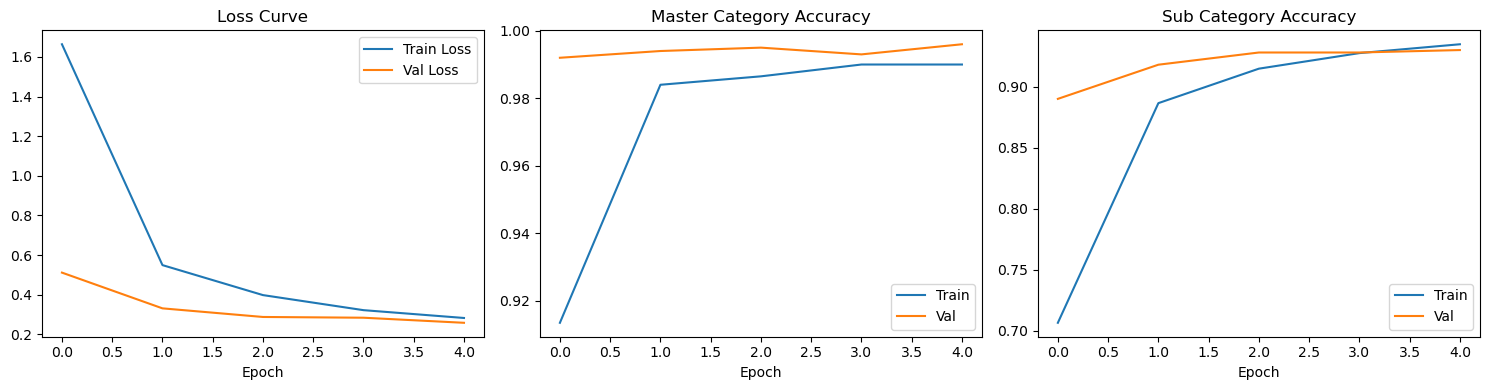

Plot saved!


In [11]:
import matplotlib.pyplot as plt

# Save model
torch.save(model.state_dict(), "fashion_model.pth")
print("Model saved!")

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Master accuracy
axes[1].plot(train_master_accs, label='Train')
axes[1].plot(val_master_accs, label='Val')
axes[1].set_title('Master Category Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Sub accuracy
axes[2].plot(train_sub_accs, label='Train')
axes[2].plot(val_sub_accs, label='Val')
axes[2].set_title('Sub Category Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()
print("Plot saved!")

In [12]:
import random

model.eval()
sample_indices = random.sample(range(len(val_df)), 5)

for idx in sample_indices:
    row = val_df.iloc[idx]
    image = row['image'].convert("RGB")
    inputs = processor(images=image, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)

    with torch.no_grad():
        master_out, sub_out, price_out = model(pixel_values)

    pred_master = le_master.classes_[master_out.argmax(1).item()]
    pred_sub = le_sub.classes_[sub_out.argmax(1).item()]
    pred_price = price_out.item() * (df['price'].max() - df['price'].min()) + df['price'].min()

    print(f"GT:   master={row['masterCategory']}, sub={row['subCategory']}, price=${row['price']:.2f}")
    print(f"Pred: master={pred_master}, sub={pred_sub}, price=${pred_price:.2f}")
    print()

GT:   master=Apparel, sub=Topwear, price=$59.82
Pred: master=Apparel, sub=Topwear, price=$49.74

GT:   master=Apparel, sub=Topwear, price=$60.68
Pred: master=Apparel, sub=Topwear, price=$50.58

GT:   master=Apparel, sub=Topwear, price=$36.95
Pred: master=Apparel, sub=Topwear, price=$69.84

GT:   master=Apparel, sub=Topwear, price=$62.68
Pred: master=Apparel, sub=Topwear, price=$48.21

GT:   master=Accessories, sub=Belts, price=$20.20
Pred: master=Accessories, sub=Belts, price=$74.80



In [13]:
# Exp 2: CLIP fine-tuning (unfreeze CLIP)
model_ft = MultiTaskFashionModel(model_clip, num_master, num_sub).to(device)

# Unfreeze CLIP weights
for param in model_ft.clip.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer_ft = optim.Adam(model_ft.parameters(), lr=1e-5)

train_losses_ft, val_losses_ft = [], []
train_master_accs_ft, val_master_accs_ft = [], []
train_sub_accs_ft, val_sub_accs_ft = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_master_acc, train_sub_acc = train_one_epoch(model_ft, train_loader, optimizer_ft)
    val_loss, val_master_acc, val_sub_acc = evaluate(model_ft, val_loader)

    train_losses_ft.append(train_loss)
    val_losses_ft.append(val_loss)
    train_master_accs_ft.append(train_master_acc)
    val_master_accs_ft.append(val_master_acc)
    train_sub_accs_ft.append(train_sub_acc)
    val_sub_accs_ft.append(val_sub_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Master Acc: {train_master_acc:.4f} | Sub Acc: {train_sub_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Master Acc: {val_master_acc:.4f} | Sub Acc: {val_sub_acc:.4f}")
    print()

Epoch 1/5
  Train Loss: 3.4710 | Master Acc: 0.9120 | Sub Acc: 0.6022
  Val   Loss: 2.1421 | Master Acc: 0.9840 | Sub Acc: 0.7420

Epoch 2/5
  Train Loss: 1.8423 | Master Acc: 0.9808 | Sub Acc: 0.7702
  Val   Loss: 1.3247 | Master Acc: 0.9830 | Sub Acc: 0.8180

Epoch 3/5
  Train Loss: 1.3037 | Master Acc: 0.9880 | Sub Acc: 0.8375
  Val   Loss: 0.9023 | Master Acc: 0.9890 | Sub Acc: 0.8830

Epoch 4/5
  Train Loss: 1.0008 | Master Acc: 0.9930 | Sub Acc: 0.8755
  Val   Loss: 0.7202 | Master Acc: 0.9890 | Sub Acc: 0.8970

Epoch 5/5
  Train Loss: 0.8069 | Master Acc: 0.9940 | Sub Acc: 0.9012
  Val   Loss: 0.6257 | Master Acc: 0.9870 | Sub Acc: 0.9180



In [14]:
NUM_EPOCHS = 5
# Exp 3: Single task (master category only)
class SingleTaskModel(nn.Module):
    def __init__(self, clip_model, num_master):
        super().__init__()
        self.clip = clip_model
        for param in self.clip.parameters():
            param.requires_grad = False

        self.fusion = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.master_head = nn.Linear(256, num_master)

    def forward(self, pixel_values):
        image_features = self.clip.get_image_features(pixel_values=pixel_values)
        x = self.fusion(image_features)
        return self.master_head(x)

model_single = SingleTaskModel(model_clip, num_master).to(device)
optimizer_single = optim.Adam(
    filter(lambda p: p.requires_grad, model_single.parameters()),
    lr=1e-3
)

train_losses_s, val_losses_s = [], []
train_master_accs_s, val_master_accs_s = [], []

for epoch in range(NUM_EPOCHS):
    model_single.train()
    total_loss, correct, total = 0, 0, 0

    for pixel_values, master_label, sub_label, price in train_loader:
        pixel_values = pixel_values.to(device)
        master_label = master_label.to(device)

        optimizer_single.zero_grad()
        out = model_single(pixel_values)
        loss = criterion_master(out, master_label)
        loss.backward()
        optimizer_single.step()

        total_loss += loss.item()
        correct += (out.argmax(1) == master_label).sum().item()
        total += len(master_label)

    train_losses_s.append(total_loss / len(train_loader))
    train_master_accs_s.append(correct / total)

    model_single.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for pixel_values, master_label, sub_label, price in val_loader:
            pixel_values = pixel_values.to(device)
            master_label = master_label.to(device)
            out = model_single(pixel_values)
            loss = criterion_master(out, master_label)
            total_loss += loss.item()
            correct += (out.argmax(1) == master_label).sum().item()
            total += len(master_label)

    val_losses_s.append(total_loss / len(val_loader))
    val_master_accs_s.append(correct / total)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_losses_s[-1]:.4f} | Master Acc: {train_master_accs_s[-1]:.4f}")
    print(f"  Val   Loss: {val_losses_s[-1]:.4f} | Master Acc: {val_master_accs_s[-1]:.4f}")
    print()

Epoch 1/5
  Train Loss: 0.0668 | Master Acc: 0.9888
  Val   Loss: 0.0763 | Master Acc: 0.9870

Epoch 2/5
  Train Loss: 0.0310 | Master Acc: 0.9952
  Val   Loss: 0.0702 | Master Acc: 0.9870

Epoch 3/5
  Train Loss: 0.0279 | Master Acc: 0.9960
  Val   Loss: 0.0660 | Master Acc: 0.9880

Epoch 4/5
  Train Loss: 0.0282 | Master Acc: 0.9965
  Val   Loss: 0.0648 | Master Acc: 0.9870

Epoch 5/5
  Train Loss: 0.0265 | Master Acc: 0.9955
  Val   Loss: 0.0739 | Master Acc: 0.9870



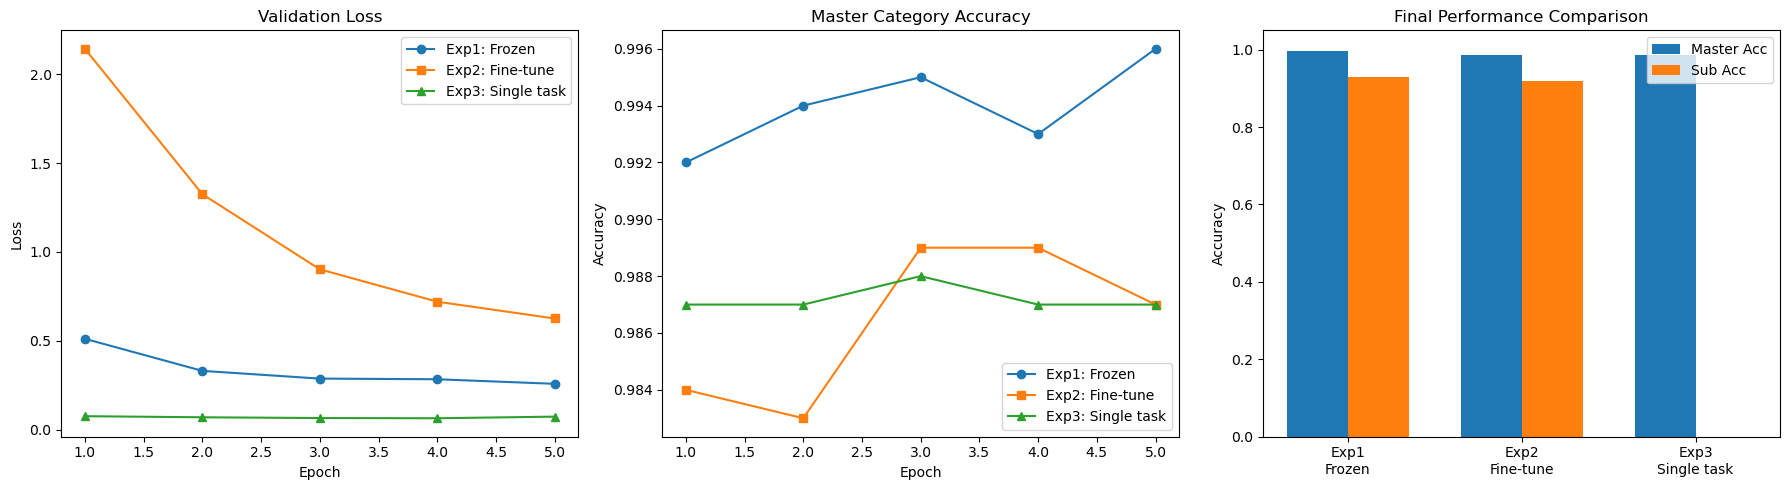

Ablation graph saved!


In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Loss comparison
axes[0].plot(epochs, val_losses, 'o-', label='Exp1: Frozen')
axes[0].plot(epochs, val_losses_ft, 's-', label='Exp2: Fine-tune')
axes[0].plot(epochs, val_losses_s, '^-', label='Exp3: Single task')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Master accuracy comparison
axes[1].plot(epochs, val_master_accs, 'o-', label='Exp1: Frozen')
axes[1].plot(epochs, val_master_accs_ft, 's-', label='Exp2: Fine-tune')
axes[1].plot(epochs, val_master_accs_s, '^-', label='Exp3: Single task')
axes[1].set_title('Master Category Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Final performance bar chart
labels = ['Exp1\nFrozen', 'Exp2\nFine-tune', 'Exp3\nSingle task']
master_accs = [val_master_accs[-1], val_master_accs_ft[-1], val_master_accs_s[-1]]
sub_accs = [val_sub_accs[-1], val_sub_accs_ft[-1], 0]

x = np.arange(len(labels))
w = 0.35
axes[2].bar(x - w/2, master_accs, w, label='Master Acc')
axes[2].bar(x + w/2, sub_accs, w, label='Sub Acc')
axes[2].set_title('Final Performance Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('ablation_results.png', dpi=150)
plt.show()
print("Ablation graph saved!")

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

class CrossAttentionFusionModel(nn.Module):
    def __init__(self, clip_model, category_texts, processor, num_master, num_sub, device):
        super().__init__()
        self.clip = clip_model
        self.device = device

        # Freeze CLIP
        for param in self.clip.parameters():
            param.requires_grad = False

        # Pre-encode category text embeddings
        with torch.no_grad():
            text_inputs = processor(
                text=category_texts,
                return_tensors="pt",
                padding=True
            ).to(device)
            self.register_buffer('text_embeds', 
                clip_model.get_text_features(**text_inputs))

        # Cross-attention
        self.attention = nn.MultiheadAttention(512, num_heads=8, batch_first=True)

        # Task heads
        self.fusion = nn.Sequential(nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3))
        self.master_head = nn.Linear(256, num_master)
        self.sub_head = nn.Linear(256, num_sub)
        self.price_head = nn.Linear(256, 1)

    def forward(self, pixel_values, return_attention=False):
        # Image features as query
        img_features = self.clip.get_image_features(pixel_values=pixel_values)
        query = img_features.unsqueeze(1)  # (B, 1, 512)

        # Text features as key/value
        kv = self.text_embeds.unsqueeze(0).expand(query.size(0), -1, -1)  # (B, N, 512)

        # Cross-attention
        attn_out, attn_weights = self.attention(query, kv, kv)
        x = self.fusion(attn_out.squeeze(1))

        master_out = self.master_head(x)
        sub_out = self.sub_head(x)
        price_out = self.price_head(x).squeeze(1)

        if return_attention:
            return master_out, sub_out, price_out, attn_weights
        return master_out, sub_out, price_out

# Category texts for text encoder
category_texts = list(le_sub.classes_)

model_ca = CrossAttentionFusionModel(
    model_clip, category_texts, processor,
    num_master, num_sub, device
).to(device)

optimizer_ca = optim.Adam(
    filter(lambda p: p.requires_grad, model_ca.parameters()),
    lr=1e-3
)

print("Cross-Attention model ready!")
print(f"Text embeddings shape: {model_ca.text_embeds.shape}")

Cross-Attention model ready!
Text embeddings shape: torch.Size([45, 512])


In [17]:
train_losses_ca, val_losses_ca = [], []
train_master_accs_ca, val_master_accs_ca = [], []
train_sub_accs_ca, val_sub_accs_ca = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_master_acc, train_sub_acc = train_one_epoch(model_ca, train_loader, optimizer_ca)
    val_loss, val_master_acc, val_sub_acc = evaluate(model_ca, val_loader)

    train_losses_ca.append(train_loss)
    val_losses_ca.append(val_loss)
    train_master_accs_ca.append(train_master_acc)
    val_master_accs_ca.append(val_master_acc)
    train_sub_accs_ca.append(train_sub_acc)
    val_sub_accs_ca.append(val_sub_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Master Acc: {train_master_acc:.4f} | Sub Acc: {train_sub_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f} | Master Acc: {val_master_acc:.4f} | Sub Acc: {val_sub_acc:.4f}")
    print()

Epoch 1/5
  Train Loss: 1.5742 | Master Acc: 0.9012 | Sub Acc: 0.6825
  Val   Loss: 0.5901 | Master Acc: 0.9890 | Sub Acc: 0.8830

Epoch 2/5
  Train Loss: 0.4326 | Master Acc: 0.9915 | Sub Acc: 0.9050
  Val   Loss: 0.5580 | Master Acc: 0.9880 | Sub Acc: 0.9030

Epoch 3/5
  Train Loss: 0.3096 | Master Acc: 0.9955 | Sub Acc: 0.9350
  Val   Loss: 0.5482 | Master Acc: 0.9890 | Sub Acc: 0.9170

Epoch 4/5
  Train Loss: 0.2943 | Master Acc: 0.9950 | Sub Acc: 0.9343
  Val   Loss: 0.5609 | Master Acc: 0.9890 | Sub Acc: 0.9080

Epoch 5/5
  Train Loss: 0.3017 | Master Acc: 0.9945 | Sub Acc: 0.9327
  Val   Loss: 0.5909 | Master Acc: 0.9890 | Sub Acc: 0.9100



In [18]:
import pickle

# Save model
torch.save(model_ca.state_dict(), 
    r"C:\Users\tjdms\OneDrive\문서\fashion-vqa\fashion_model_ca.pth")

# Save label encoders
with open(r"C:\Users\tjdms\OneDrive\문서\fashion-vqa\label_encoders.pkl", "wb") as f:
    pickle.dump({
        "le_master": le_master,
        "le_sub": le_sub,
        "price_min": df['price'].min(),
        "price_max": df['price'].max()
    }, f)

print("Model and encoders saved!")

Model and encoders saved!


In [19]:
pip install gradio

In [20]:
import gradio as gr
import torch
from PIL import Image

def predict(image):
    if image is None:
        return "Upload an image", "Upload an image", 0.0, None
    
    # Preprocess
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        master_out, sub_out, price_out, attn_weights = model_ca(
            inputs["pixel_values"], return_attention=True
        )
    
    pred_master = le_master.classes_[master_out.argmax(1).item()]
    pred_sub = le_sub.classes_[sub_out.argmax(1).item()]
    pred_price = price_out.item() * (df['price'].max() - df['price'].min()) + df['price'].min()
    
    # Attention visualization
    attn = attn_weights.squeeze().tolist()
    top5_idx = sorted(range(len(attn)), key=lambda i: attn[i], reverse=True)[:5]
    attn_result = {le_sub.classes_[i]: float(attn[i]) for i in top5_idx}
    
    return pred_master, pred_sub, round(pred_price, 2), attn_result

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Product Image"),
    outputs=[
        gr.Text(label="Category"),
        gr.Text(label="Sub-category"),
        gr.Number(label="Estimated Price ($)"),
        gr.Label(label="Attention Weights (Top 5)")
    ],
    title="Fashion Product Analyzer",
    description="Upload a product image to predict category and price using CLIP + Cross-Attention",
    examples=[]
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f860a2fd3d165bdf00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
